In [22]:
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs

In [23]:
class KMeans:
    def __init__(self, k,max_iter=100):
        self.k = k
        self.max_iter = max_iter

    def centroid_init(self,X):
        random_indices = np.random.choice(X.shape[0], self.k, replace=False)
        return X[random_indices]

    def fit(self, X):
        self.centroids = self.centroid_init(X)

        for _ in range(self.max_iter):
            distances=[]
            for point in X:
                d=[]
                for center in self.centroids:
                    d.append(np.sqrt(np.sum((point-center)**2)))
                distances.append(d)
            labels=[]
            for d in distances:
                labels.append(np.argmin(d))
            labels = np.array(labels)

            new_centroids=[]
            for i in range(self.k):
                points = X[labels == i]
                if len(points) > 0:
                    new_centroids.append(np.mean(points, axis=0))
                else:
                    new_centroids.append(self.centroids[i])
            new_centroids = np.array(new_centroids)

            if np.all(new_centroids == self.centroids):
                break
            self.centroids = new_centroids
        self.labels_= labels
    
    def predict(self, X):
        labels=[]
        for point in X:
            d=[]
            for center in self.centroids:
                d.append(np.sqrt(np.sum((point-center)**2)))
            labels.append(np.argmin(d))
        return np.array(labels)





X,y = make_blobs(n_samples=50, centers=3, random_state=42, cluster_std=1.0)
kmeans = KMeans(k=3)
kmeans.fit(X)

#more y points needed




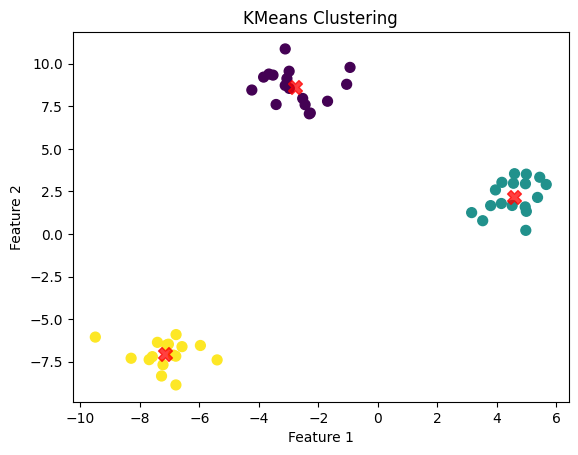

In [24]:

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=50, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', s=100, alpha=0.75, marker='X')
plt.title('KMeans Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()
